# Feature-axis validation — is `design_name` really the right client axis?

Encode the CircuitNet-N28 factorial design matrix (one-hot `design_name` + the six other metadata knobs),
PCA it, and then run variance decomposition + three geometric probes to see
which factor structures the shared metadata space. Whichever factor consistently
dominates earns the FL client axis.

## Workflow

1. Parse filenames into a factorial design matrix.
2. One-hot `design_name`, then QuantileTransform + StandardScaler + 12-component PCA.
3. Print top loadings + recolor PC1/PC2 by each factor.
4. Variance-weighted η² decomposition per factor across all 12 PCs.
5. Clustering + neighborhood probes on the first 3 PCs: K-means, Ward
   hierarchical, kNN label agreement.
6. Final verdict + references.

# Imports

In [35]:
import os, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm

from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5', 'figure.facecolor': 'white',
})

FEATURE_DIR = '../routability_ir_drop_prediction/training_set_N28/DRC/feature'
SEED = 42
print('Imports OK.')

Imports OK.


# Parse filenames 

In [36]:
def parse_sample_name(filename: str) -> dict:
    basename = filename.replace('.npy', '')
    parts = basename.split('-')
    if parts[0].isdigit():
        parts = parts[1:]
    for expected, token in zip(['c','u','m','p','f'], parts[-5:]):
        if not token.startswith(expected):
            raise ValueError(f'Bad token {token} in {filename}')
    c, u, m, p, f = parts[-5:]

    design_name = '-'.join(parts[:-6])
    variant = design_name.split('-')[-1]
    macro_count = int(parts[-6])

    if not macro_count:
        macro_count = 1

    if variant == 'a' and macro_count in (1, 2, 3):
        macro_count += 2
    if variant == 'b':
        if macro_count in (1, 2, 3):
            macro_count += 12
        else:
            macro_count += 10

    return {
        'design_name':      design_name,
        'macro_count':      macro_count,
        'clock_ns':         float(c[1:]),
        'utilization':      float(u[1:]),
        'macro_placement':  m[1:],
        'power_mesh':       p[1:],
        'filler_insertion': f[1:],
        'filename':         filename,
    }

files = sorted(f for f in os.listdir(FEATURE_DIR) if f.endswith('.npy'))
df_meta = pd.DataFrame([parse_sample_name(f) for f in files])
df_meta.loc[~df_meta['macro_placement'].isin(['1','2','3','4']), 'macro_placement'] = '1'

FACTOR_COLS = ['design_name','macro_count','clock_ns',
               'utilization','macro_placement','power_mesh','filler_insertion']

df_meta = df_meta[df_meta['design_name'] == 'RISCY-FPU-a']
print(f'Samples: {len(df_meta)}')
print('Unique-value counts per factor:')
for c in FACTOR_COLS:
    print(f'  {c:20s} {df_meta[c].nunique():3d}')

Samples: 1969
Unique-value counts per factor:
  design_name            1
  macro_count            3
  clock_ns               3
  utilization            5
  macro_placement        4
  power_mesh             8
  filler_insertion       2


# Factor level frequencies

Factor level frequencies   (n = 1969 samples)

--- design_name   (1 levels) ---
             count  percent
design_name                
RISCY-FPU-a   1969    100.0

--- macro_count   (3 levels) ---
             count  percent
macro_count                
3              737    37.43
4              597    30.32
5              635    32.25

--- clock_ns   (3 levels) ---
          count  percent
clock_ns                
2.0         681    34.59
5.0         689    34.99
20.0        599    30.42

--- utilization   (5 levels) ---
             count  percent
utilization                
0.7            453    23.01
0.75           460    23.36
0.8            454    23.06
0.85           371    18.84
0.9            231    11.73

--- macro_placement   (4 levels) ---
                 count  percent
macro_placement                
1                  620    31.49
2                  539    27.37
3                  575    29.20
4                  235    11.93

--- power_mesh   (8 levels) ---
            c

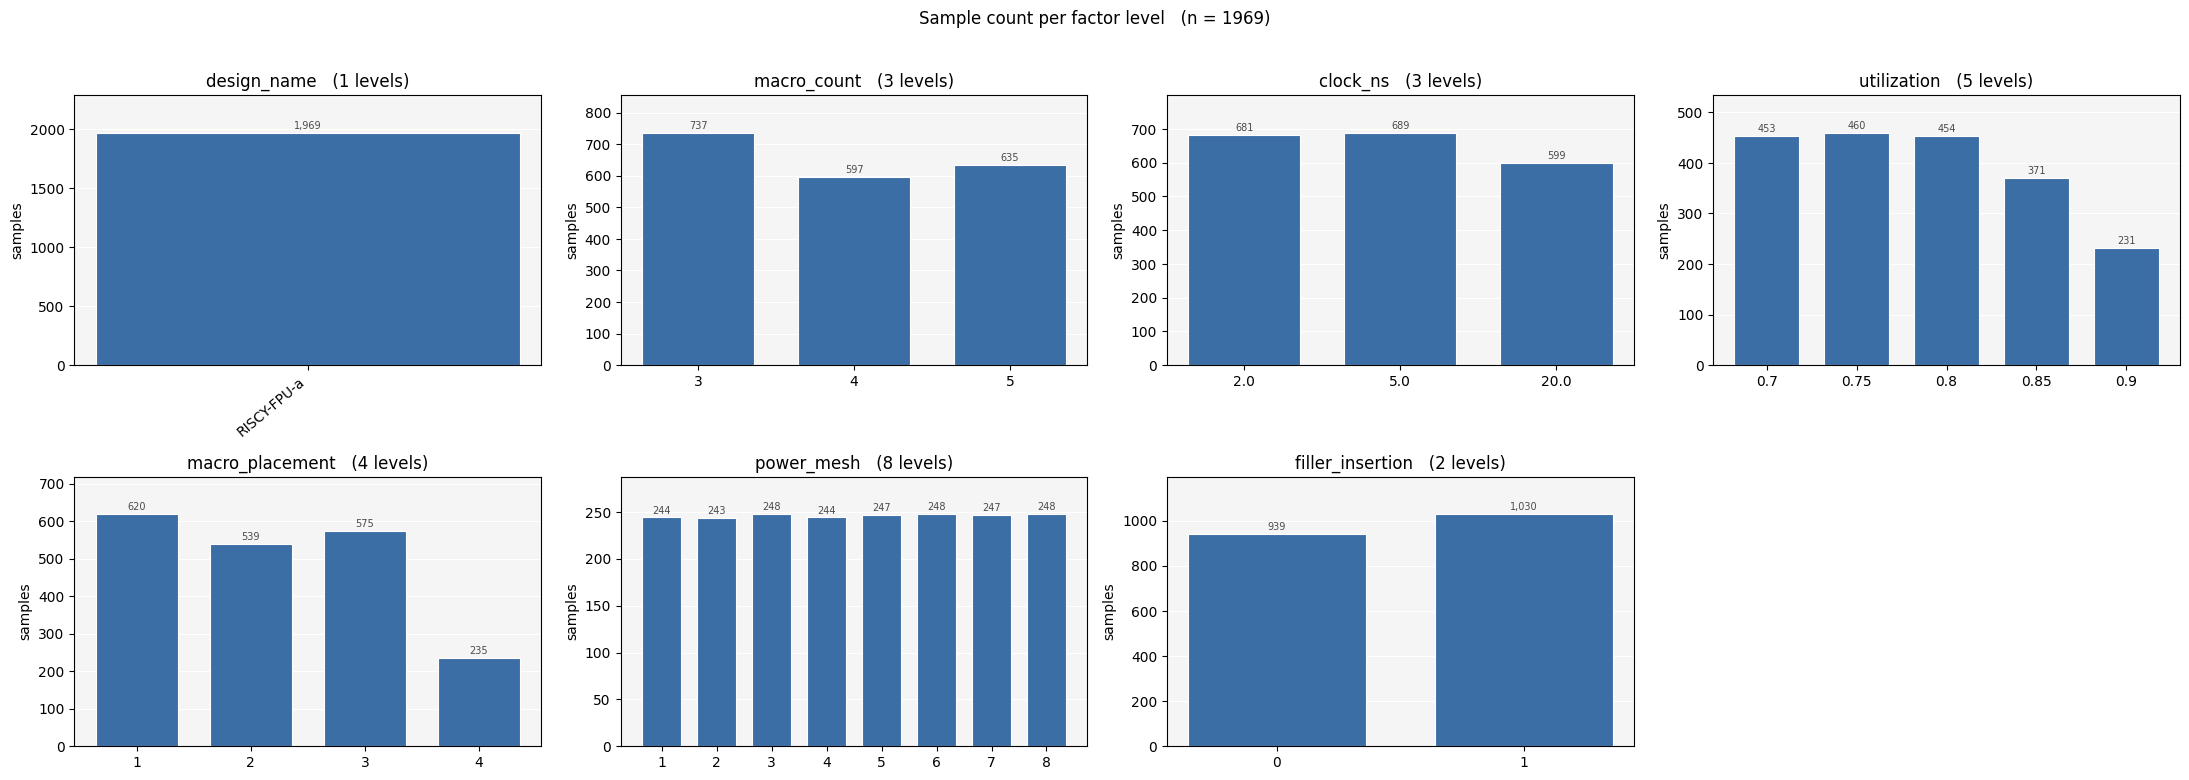

In [37]:
BAR_COLOR = '#3b6ea5'


def factor_levels(series):
    """Level labels of a factor, numerically ordered when possible."""
    vals = series.astype(str).unique()
    try:
        return sorted(vals, key=float)
    except ValueError:
        return sorted(vals)


def frequency_table(df, col):
    """Sample count and share of the corpus per level of `col`."""
    levels = factor_levels(df[col])
    counts = (df[col].astype(str).value_counts()
              .reindex(levels).fillna(0).astype(int))
    tbl = pd.DataFrame({'count': counts})
    tbl['percent'] = (tbl['count'] / len(df) * 100).round(2)
    tbl.index.name = col
    return tbl


def print_frequency_tables(df, factor_cols):
    print('=' * 72)
    print(f'Factor level frequencies   (n = {len(df)} samples)')
    print('=' * 72)
    balance = []
    for f in factor_cols:
        tbl = frequency_table(df, f)
        print(f'\n--- {f}   ({len(tbl)} levels) ---')
        print(tbl.to_string())
        balance.append({
            'factor':    f,
            'levels':    len(tbl),
            'min_count': int(tbl['count'].min()),
            'max_count': int(tbl['count'].max()),
            'imbalance': round(tbl['count'].max() / max(tbl['count'].min(), 1), 2),
        })
    print('\n--- balance summary   (imbalance = max/min level count) ---')
    print(pd.DataFrame(balance).set_index('factor').to_string())


def plot_factor_frequencies(df, factor_cols, ncols=4, color=BAR_COLOR):
    nrows = int(np.ceil(len(factor_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, f in zip(axes, factor_cols):
        tbl = frequency_table(df, f)
        levels = [str(x) for x in tbl.index]
        xs = np.arange(len(levels))
        ax.bar(xs, tbl['count'], width=0.72, color=color,
               edgecolor='white', linewidth=0.8)
        for x, n in zip(xs, tbl['count']):
            ax.annotate(f'{n:,}', (x, n), textcoords='offset points',
                        xytext=(0, 3), ha='center', fontsize=7, color='#4a4a4a')
        ax.set_xticks(xs)
        ax.set_xticklabels(levels)
        if max(len(l) for l in levels) > 6:
            ax.tick_params(axis='x', labelrotation=40)
            for lab in ax.get_xticklabels():
                lab.set_ha('right')
        ax.set_title(f'{f}   ({len(levels)} levels)')
        ax.set_ylabel('samples')
        ax.set_ylim(0, tbl['count'].max() * 1.16)
        ax.set_axisbelow(True)
        ax.xaxis.grid(False)
    for ax in axes[len(factor_cols):]:
        ax.axis('off')
    fig.suptitle(f'Sample count per factor level   (n = {len(df)})', y=1.02)
    plt.tight_layout(); plt.show()


print_frequency_tables(df_meta, FACTOR_COLS)
plot_factor_frequencies(df_meta, FACTOR_COLS)

# Preprocess + PCA

One-hot `design_name` (6 columns) and keep the other six factors as numeric
codes. `QuantileTransformer` maps every column to a Gaussian marginal so no
single knob dominates purely by scale, then `StandardScaler` re-centers, then
a 12-component PCA (the design matrix has 12 columns after one-hot, so 12 PCs
capture the entire variance; PC12 is numerically zero because of the one-hot
sum-to-one collinearity).

Twelve components are kept regardless of any explained-variance elbow because
the variance-decomposition below needs a fixed PC set across every factor to
be comparable.

Index(['macro_count', 'clock_ns', 'utilization', 'macro_placement',
       'power_mesh', 'filler_insertion'],
      dtype='object')
Explained variance ratio:
  PC 1: 0.216   cumulative=0.216
  PC 2: 0.181   cumulative=0.397
  PC 3: 0.173   cumulative=0.570
  PC 4: 0.167   cumulative=0.737
  PC 5: 0.143   cumulative=0.880
  PC 6: 0.120   cumulative=1.000


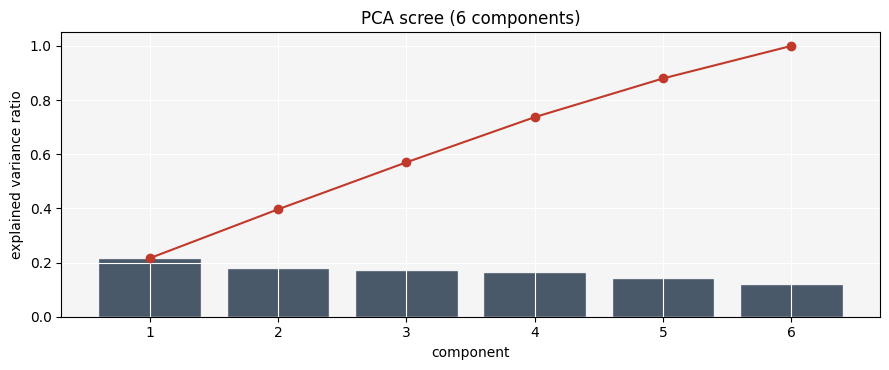

In [38]:
subset = df_meta
# new_subset = pd.get_dummies(subset, columns=['design_name'], dtype='uint8')
new_subset = subset.drop(columns=['filename', 'design_name'])
print(new_subset.columns)

X = new_subset[new_subset.columns].to_numpy()

qt = QuantileTransformer(output_distribution='normal', random_state=SEED,
                         n_quantiles=min(1000, len(X)))
X_qt = qt.fit_transform(X)
sc = StandardScaler()
X_std = sc.fit_transform(X)

N_PC = X_std.shape[1]
pca = PCA(n_components=N_PC, random_state=SEED)
Z = pca.fit_transform(X_std)
evr = pca.explained_variance_ratio_
print('Explained variance ratio:')
for i, v in enumerate(evr):
    print(f'  PC{i + 1:2d}: {v:.3f}   cumulative={evr[:i + 1].sum():.3f}')

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(range(1, N_PC + 1), evr, alpha=0.85, color='#2c3e50', edgecolor='white')
ax.plot(range(1, N_PC + 1), np.cumsum(evr), marker='o', color='#c0392b')
ax.set_xlabel('component'); ax.set_ylabel('explained variance ratio')
ax.set_title('PCA scree (' + str(N_PC) + ' components)')
plt.tight_layout()
plt.show()

# PC loadings + recolored PC1/PC2 scatter

Print the top-10 columns by absolute loading on PC1/PC2/PC3, then plot the
same PC1/PC2 scatter recolored by five metadata factors. A factor that
produces visibly separated clusters is one the leading PCs encode directly.


Top-10 |loadings| on PC1:
  -0.687  filler_insertion
  +0.596  macro_placement
  -0.368  utilization
  -0.140  clock_ns
  -0.127  macro_count
  +0.036  power_mesh

Top-10 |loadings| on PC2:
  +0.683  utilization
  -0.618  macro_count
  +0.283  macro_placement
  -0.262  clock_ns
  +0.049  filler_insertion
  +0.023  power_mesh

Top-10 |loadings| on PC3:
  +0.804  clock_ns
  -0.538  macro_count
  -0.144  macro_placement
  -0.139  filler_insertion
  -0.114  power_mesh
  -0.105  utilization


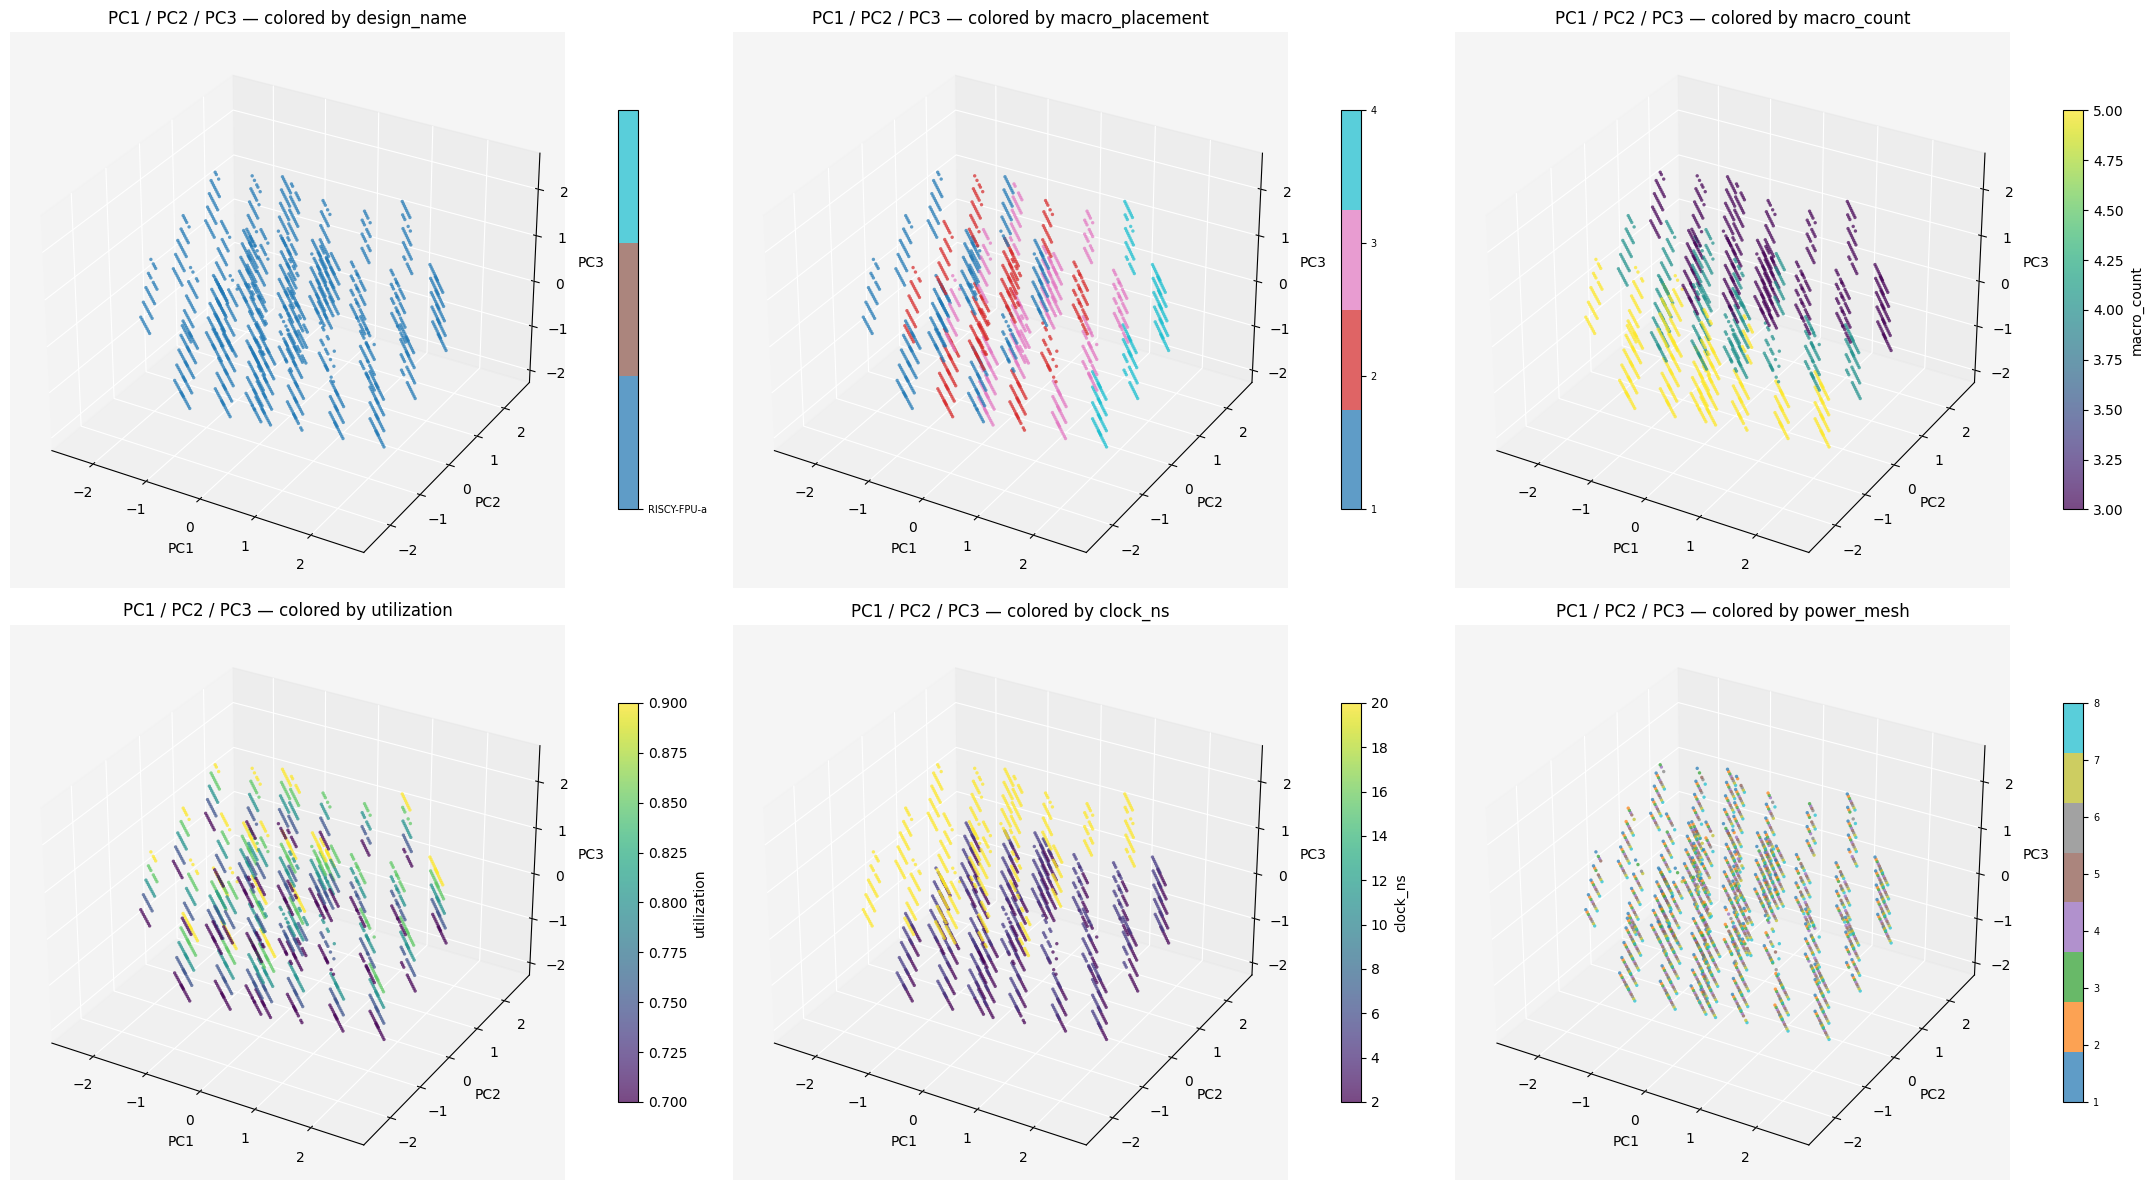

In [39]:
loadings = pd.DataFrame(pca.components_.T, index=new_subset.columns,
                        columns=[f'PC{i + 1}' for i in range(pca.n_components_)])

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(10)
    print(f'\nTop-10 |loadings| on {pc}:')
    for name in top.index:
        print(f'  {loadings.loc[name, pc]:+.3f}  {name}')

recolor_factors = ['design_name', 'macro_placement', 'macro_count',
                   'utilization', 'clock_ns', 'power_mesh']
fig = plt.figure(figsize=(22, 12))
for i, factor in enumerate(recolor_factors):
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    if pd.api.types.is_numeric_dtype(subset[factor]):
        codes = subset[factor].to_numpy()
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=codes, cmap='viridis',
                         s=6, alpha=0.7, edgecolor='none', depthshade=False)
        plt.colorbar(sc_, ax=ax, fraction=0.03, pad=0.08, label=factor)
    else:
        levels = sorted(subset[factor].astype(str).unique())
        code_map = {l: i for i, l in enumerate(levels)}
        codes = subset[factor].astype(str).map(code_map).to_numpy()
        cmap = mcm.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=codes, cmap=cmap,
                         s=6, alpha=0.7, edgecolor='none', depthshade=False,
                         vmin=0, vmax=max(len(levels) - 1, 1))
        cbar = plt.colorbar(sc_, ax=ax, ticks=range(len(levels)),
                            fraction=0.03, pad=0.08)
        cbar.set_ticklabels(levels)
        cbar.ax.tick_params(labelsize=7)
    ax.set_title(f'PC1 / PC2 / PC3 — colored by {factor}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
plt.tight_layout()
plt.show()

df_full = subset

# Variance decomposition — variance-weighted η² on the leading PCs

Instead of PERMANOVA (which needs an n × n distance matrix), compute per-PC
η² of each factor via one-way ANOVA and sum the contributions weighted by
that PC's explained variance. The `weighted_total` column approximates the
*fraction of factorial-design variance explained by that factor*. Balanced
factorial ⇒ these numbers can be read semi-quantitatively.

          factor  n_levels  eta2_PC1  eta2_PC2  eta2_PC3  eta2_PC4  eta2_PC5  eta2_PC6  weighted_total
 macro_placement         4     0.501     0.092     0.022     0.015     0.222     0.278           0.196
filler_insertion         2     0.612     0.003     0.020     0.001     0.000     0.364           0.180
     utilization         5     0.183     0.507     0.012     0.002     0.181     0.139           0.176
     macro_count         3     0.022     0.414     0.301     0.007     0.232     0.030           0.170
        clock_ns         3     0.026     0.074     0.673     0.003     0.224     0.002           0.168
      power_mesh         8     0.002     0.001     0.014     0.974     0.008     0.002           0.167


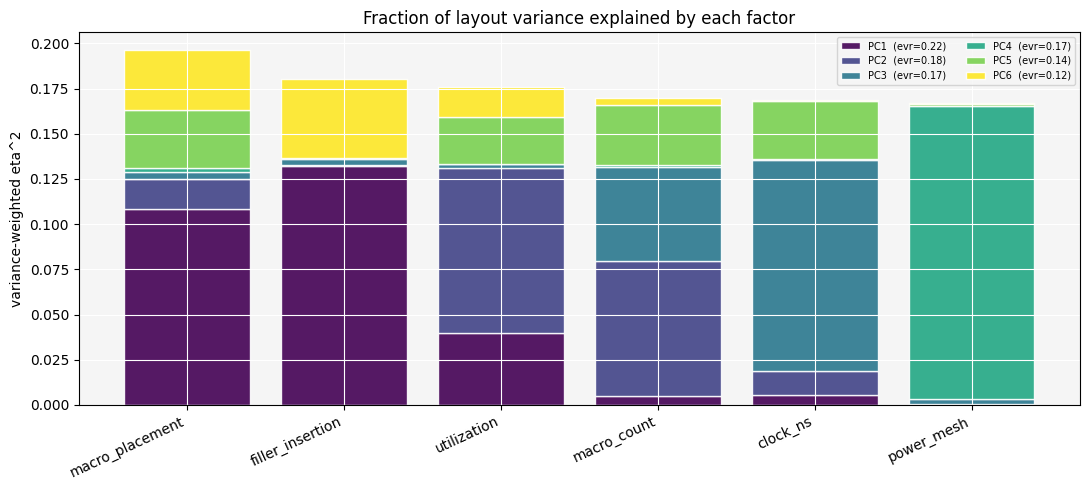

In [40]:
def eta_sq(y_num, groups):
    d = pd.DataFrame({'y': y_num, 'g': groups}).dropna()
    grand = d['y'].mean()
    ss_tot = ((d['y'] - grand) ** 2).sum()
    if ss_tot == 0:
        return 0.0
    ss_bet = sum(len(g) * (g['y'].mean() - grand) ** 2
                 for _, g in d.groupby('g'))
    return float(ss_bet / ss_tot)


K_PC = pca.n_components_
eta_rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    groups = df_full[f].astype(str).to_numpy()
    row = {'factor': f, 'n_levels': int(df_full[f].nunique())}
    for k in range(K_PC):
        row[f'eta2_PC{k + 1}'] = round(eta_sq(Z[:, k], groups), 3)
    row['weighted_total'] = round(sum(
        row[f'eta2_PC{k + 1}'] * evr[k] for k in range(K_PC)
    ), 3)
    eta_rows.append(row)
eta_df = pd.DataFrame(eta_rows).sort_values('weighted_total', ascending=False)
print(eta_df.to_string(index=False))

top_factors = eta_df.head(6)['factor'].tolist()
fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(top_factors))
cmap = mcm.get_cmap('viridis', K_PC)
for k in range(K_PC):
    heights = np.array([
        eta_df.set_index('factor').loc[f, f'eta2_PC{k + 1}'] * evr[k]
        for f in top_factors
    ])
    ax.bar(top_factors, heights, bottom=bottom, color=cmap(k),
           label=f'PC{k + 1}  (evr={evr[k]:.2f})',
           edgecolor='white', alpha=0.9)
    bottom += heights
ax.set_ylabel('variance-weighted eta^2')
ax.set_title('Fraction of layout variance explained by each factor')
ax.legend(fontsize=7, loc='upper right', ncol=2)
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()

# Clustering + neighborhood diagnostics on the first 3 PCs

Order:

1. **K-means** — k sweep with silhouette; ARI/NMI at the best-silhouette k
   against every metadata factor.
2. **Hierarchical (Ward)** — dendrogram + ARI/NMI at the same k. Tests
   whether the metadata hierarchy sits at the top of the tree, and cross-
   checks the k-means partition with a different objective.
3. **kNN label agreement** — for each factor, fraction of a sample's k
   nearest neighbors that share its label, vs chance. Model-free, no k to
   pick beyond the neighborhood size, and gives a per-factor number without
   needing to assume a partition.

## K-means — k sweep + label agreement

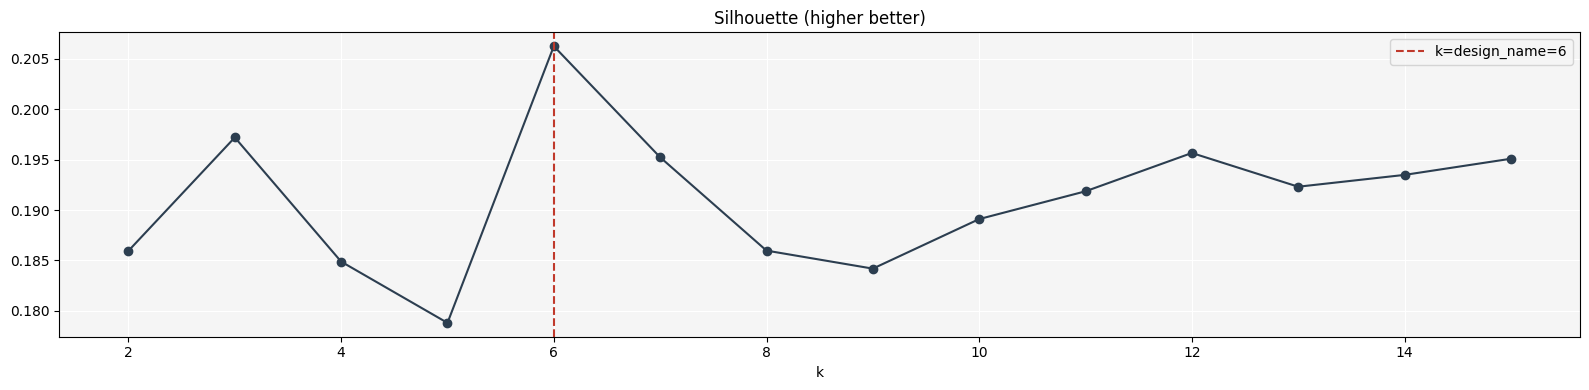

Best-silhouette k = 6   (silhouette = 0.206)


In [41]:
Z3 = Z
ks = list(range(2, 16))
sil, dbi, inertia = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lab = km.fit_predict(Z3)
    sil.append(silhouette_score(Z3, lab))

k_best_sil = ks[int(np.argmax(sil))]
fig, axes = plt.subplots(1, 1, figsize=(16, 4))
axes.plot(ks, sil, marker='o', color='#2c3e50')
axes.axvline(k_best_sil, ls='--', color='#c0392b', label=f'k=design_name={k_best_sil}')
axes.set_title('Silhouette (higher better)')
axes.set_xlabel('k')
axes.legend()
plt.tight_layout(); plt.show()

print(f'Best-silhouette k = {k_best_sil}   (silhouette = {max(sil):.3f})')


In [42]:
# SET K HERE
k_design = 6
print(f'Using k_design = {k_design} for clustering and evaluation.')

Using k_design = 6 for clustering and evaluation.



ARI / NMI of k-means labels (k=6) vs each metadata factor:
  macro_count          ARI=+0.006  NMI=0.010
  clock_ns             ARI=+0.261  NMI=0.426
  utilization          ARI=+0.074  NMI=0.136
  macro_placement      ARI=+0.107  NMI=0.218
  power_mesh           ARI=-0.003  NMI=0.000
  filler_insertion     ARI=+0.335  NMI=0.558


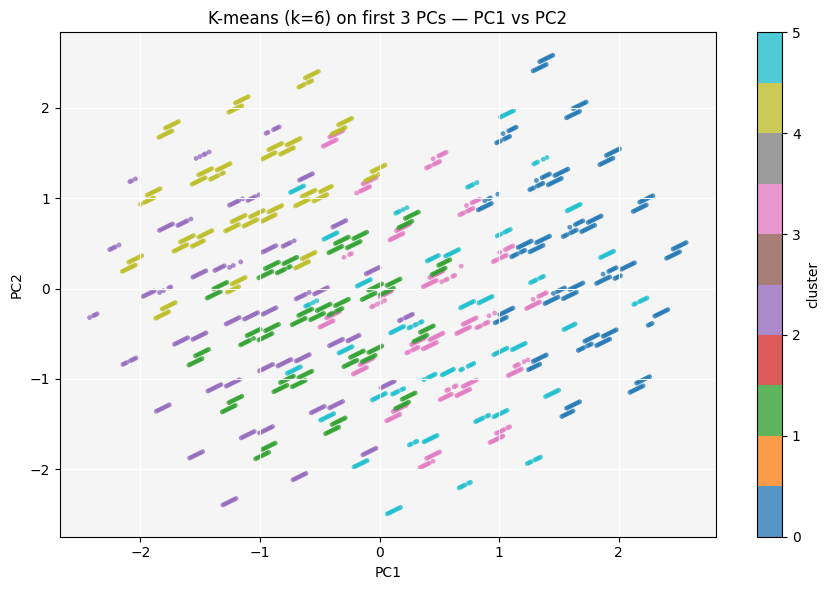

In [43]:
km = KMeans(n_clusters=k_design, n_init=10, random_state=SEED)
lab_km = km.fit_predict(Z3)
print(f'\nARI / NMI of k-means labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_km)
    nmi = normalized_mutual_info_score(y, lab_km)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')
k_design = 6

fig, ax = plt.subplots(figsize=(9, 6))
sc_ = ax.scatter(Z3[:, 0], Z3[:, 1], c=lab_km, cmap='tab10',
                 s=12, alpha=0.75, edgecolor='none')
ax.set_title(f'K-means (k={k_design}) on first 3 PCs — PC1 vs PC2')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(sc_, ax=ax, label='cluster')
plt.tight_layout()
plt.show()

## Hierarchical (Ward) — dendrogram + label agreement

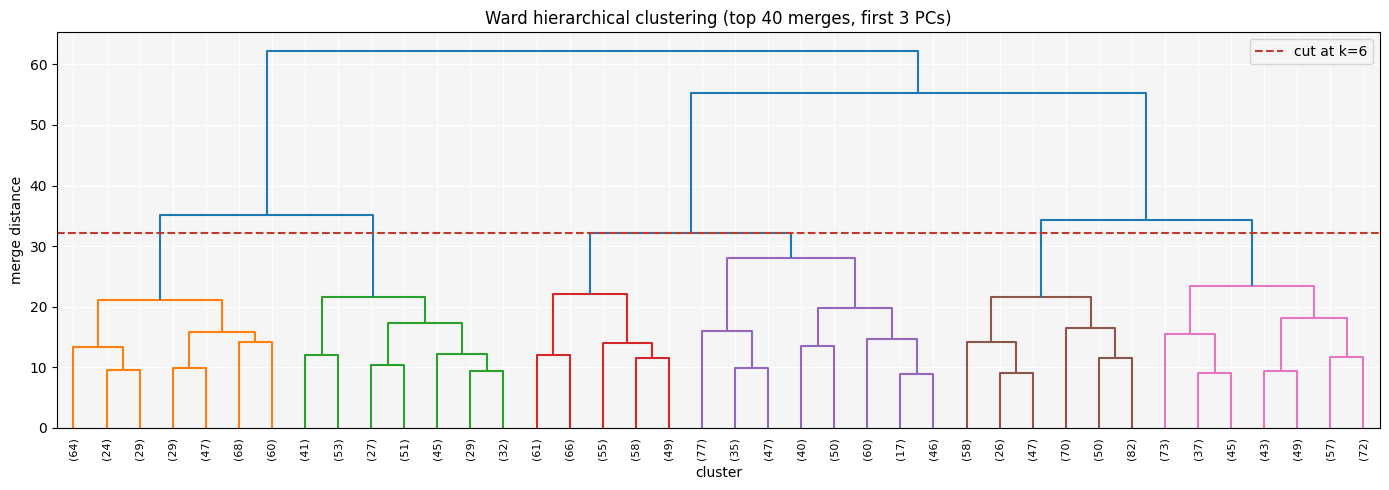

Hierarchical @ k=6  silhouette = 0.185   (k-means @ k=6 silhouette = 0.206)

ARI / NMI of hierarchical labels (k=6) vs each metadata factor:
  macro_count          ARI=+0.028  NMI=0.035
  clock_ns             ARI=+0.261  NMI=0.427
  utilization          ARI=+0.073  NMI=0.133
  macro_placement      ARI=+0.062  NMI=0.129
  power_mesh           ARI=-0.002  NMI=0.001
  filler_insertion     ARI=+0.336  NMI=0.559


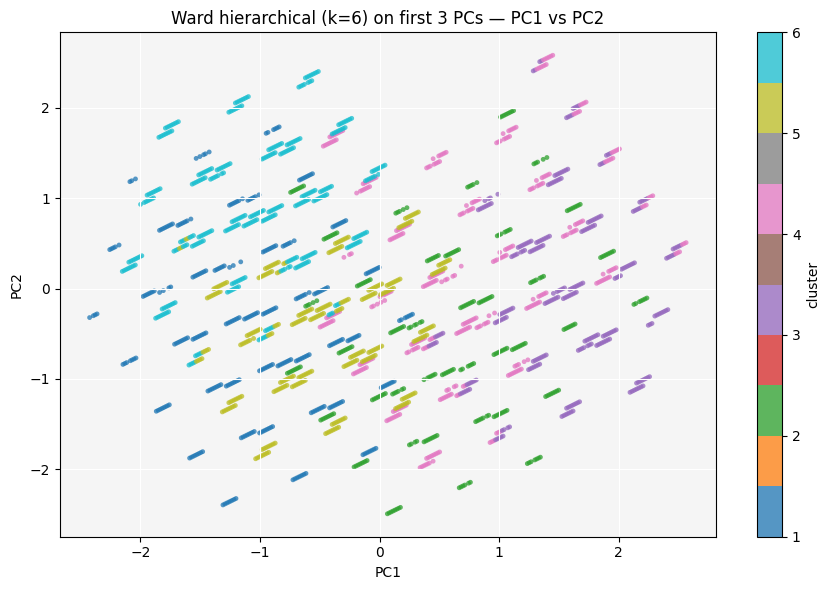

In [44]:
Z_link = linkage(Z3, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z_link, 
    truncate_mode='lastp', 
    p=40,
    leaf_rotation=90, 
    leaf_font_size=8, 
    ax=ax,
    color_threshold=Z_link[-(k_design - 1), 2]
)
ax.axhline(
    Z_link[-(k_design - 1), 2], 
    ls='--', 
    color='#c0392b',
    label=f'cut at k={k_design}'
)
ax.set_title(f'Ward hierarchical clustering (top 40 merges, first 3 PCs)')
ax.set_xlabel('cluster')
ax.set_ylabel('merge distance')
ax.legend()
plt.tight_layout(); plt.show()

lab_hier = fcluster(Z_link, t=k_design, criterion='maxclust')
sil_hier = silhouette_score(Z3, lab_hier)
print(f'Hierarchical @ k={k_design}  silhouette = {sil_hier:.3f}   '
      f'(k-means @ k={k_design} silhouette = {sil[ks.index(k_design)]:.3f})')

print(f'\nARI / NMI of hierarchical labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_hier)
    nmi = normalized_mutual_info_score(y, lab_hier)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')

fig, ax = plt.subplots(figsize=(9, 6))
sc_ = ax.scatter(Z3[:, 0], Z3[:, 1], c=lab_hier, cmap='tab10',
                 s=12, alpha=0.75, edgecolor='none')
ax.set_title(f'Ward hierarchical (k={k_design}) on first 3 PCs — PC1 vs PC2')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(sc_, ax=ax, label='cluster')
plt.tight_layout()
plt.show()

## Per-cluster feature distribution


K-means (k = 6): per-cluster feature distribution

Cluster sizes: {0: 353, 1: 380, 2: 321, 3: 308, 4: 329, 5: 278}   (total = 1969)

--- design_name   (% within each cluster) ---
Empty DataFrame
Columns: []
Index: []

--- macro_count   (% within each cluster) ---
Empty DataFrame
Columns: []
Index: []

--- clock_ns   (% within each cluster) ---
Empty DataFrame
Columns: []
Index: []

--- utilization   (% within each cluster) ---
Empty DataFrame
Columns: []
Index: []

--- macro_placement   (% within each cluster) ---
Empty DataFrame
Columns: []
Index: []

--- power_mesh   (% within each cluster) ---
Empty DataFrame
Columns: []
Index: []

--- filler_insertion   (% within each cluster) ---
Empty DataFrame
Columns: []
Index: []

Ward hierarchical (k = 6): per-cluster feature distribution

Cluster sizes: {1: 321, 2: 278, 3: 289, 4: 372, 5: 333, 6: 376}   (total = 1969)

--- design_name   (% within each cluster) ---
Empty DataFrame
Columns: []
Index: []

--- macro_count   (% within each clust

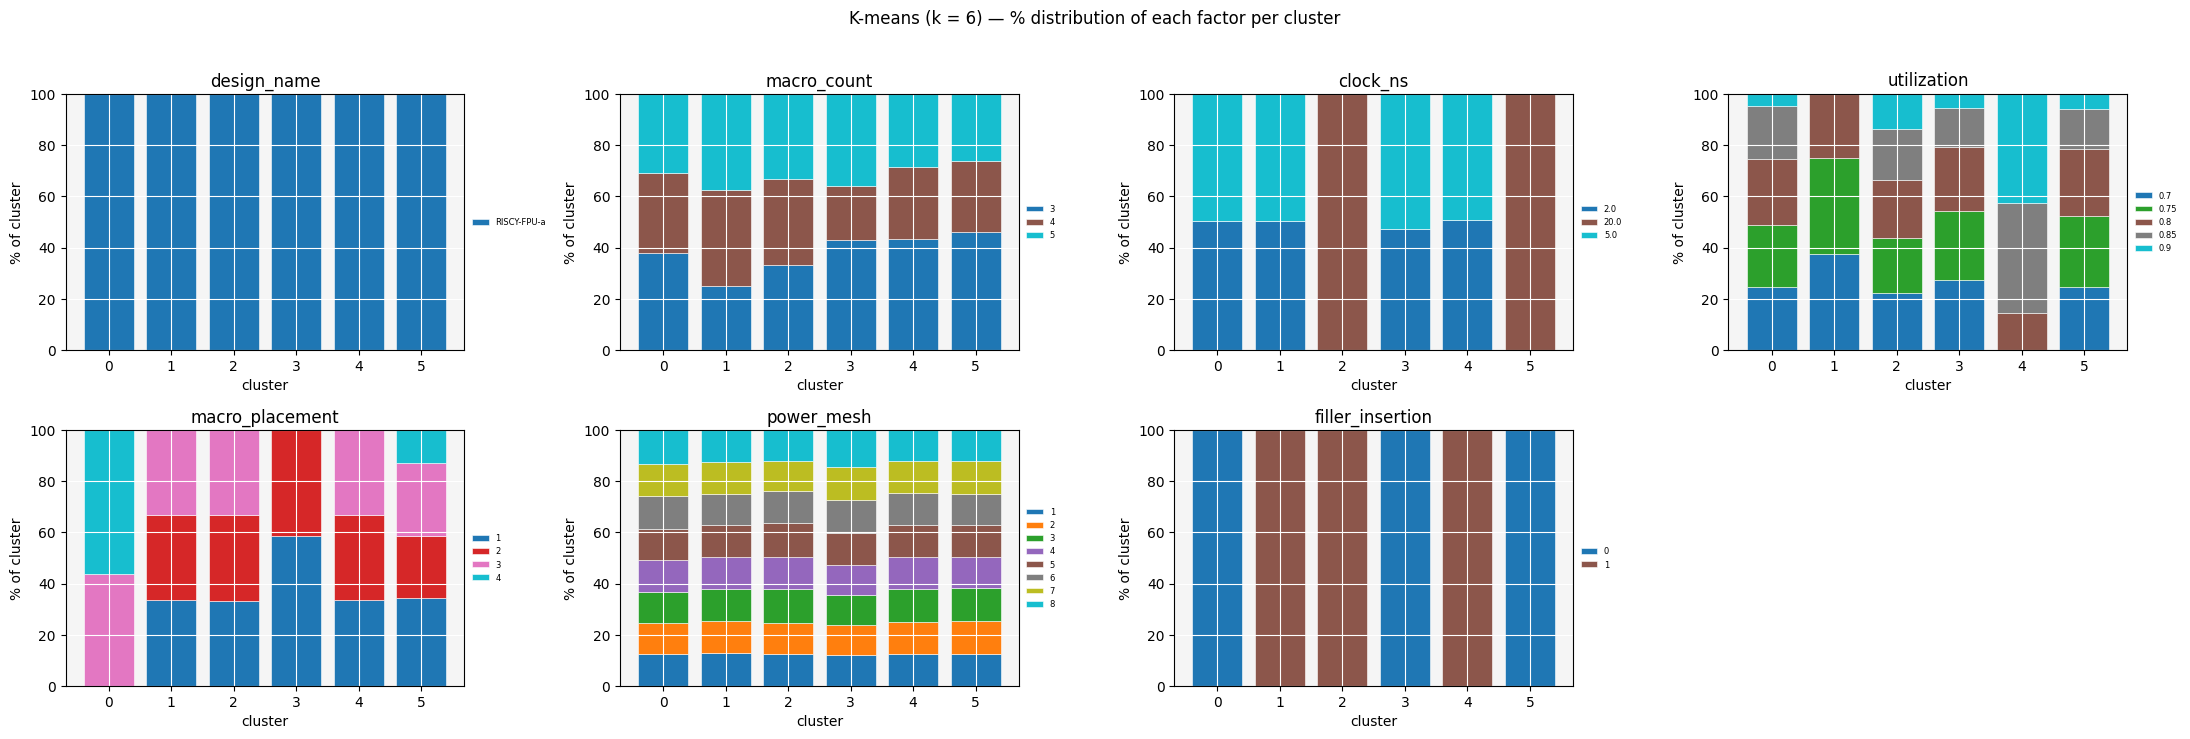

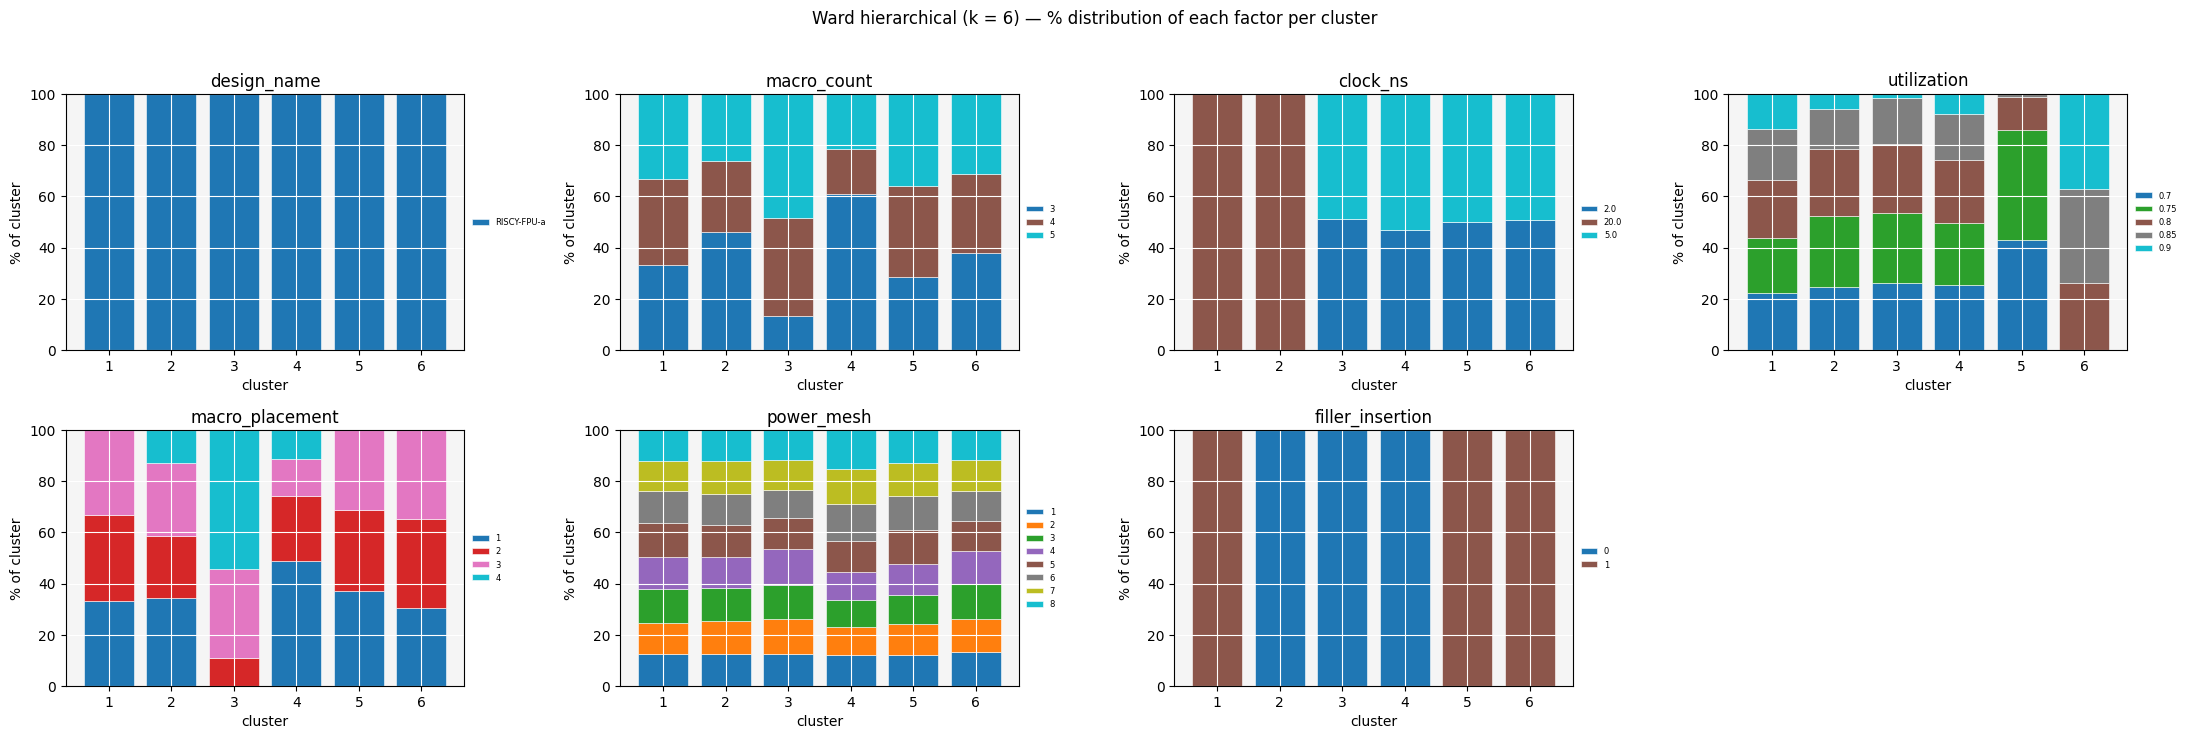

In [45]:
def per_cluster_tables(labels, method_name, df, factor_cols):
    lab_series = pd.Series(labels, name='cluster')
    sizes = lab_series.value_counts().sort_index()
    print(f'\n{"=" * 72}')
    print(f'{method_name}: per-cluster feature distribution')
    print(f'{"=" * 72}')
    print(f'\nCluster sizes: {dict(sizes)}   (total = {sizes.sum()})')
    for f in factor_cols:
        ct = pd.crosstab(lab_series, df[f].astype(str), normalize='index') * 100
        ct = ct.round(1)
        ct.index.name = 'cluster'
        print(f'\n--- {f}   (% within each cluster) ---')
        print(ct.to_string())


def plot_per_cluster(labels, method_name, df, factor_cols, ncols=4):
    cluster_ids = sorted(np.unique(labels))
    nfac = len(factor_cols)
    nrows = int(np.ceil(nfac / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.6 * nrows))
    axes = axes.ravel()
    for i, f in enumerate(factor_cols):
        ax = axes[i]
        levels = sorted(df[f].astype(str).unique())
        counts = np.zeros((len(cluster_ids), len(levels)))
        for ci, c in enumerate(cluster_ids):
            mask = labels == c
            vc = df.loc[mask, f].astype(str).value_counts()
            for li, l in enumerate(levels):
                counts[ci, li] = vc.get(l, 0)
        row_sums = np.maximum(counts.sum(axis=1, keepdims=True), 1)
        pct = counts / row_sums * 100
        bottom = np.zeros(len(cluster_ids))
        cmap = plt.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        xtick = [str(c) for c in cluster_ids]
        for li, l in enumerate(levels):
            ax.bar(xtick, pct[:, li], bottom=bottom, color=cmap(li),
                   label=str(l), edgecolor='white', linewidth=0.4)
            bottom += pct[:, li]
        ax.set_title(f)
        ax.set_xlabel('cluster')
        ax.set_ylabel('% of cluster')
        ax.set_ylim(0, 100)
        ax.legend(fontsize=6, loc='center left', bbox_to_anchor=(1, 0.5),
                  frameon=False)
    for j in range(nfac, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{method_name} — % distribution of each factor per cluster',
                 y=1.02)
    plt.tight_layout(); plt.show()


km_name   = f'K-means (k = {len(np.unique(lab_km))})'
hier_name = f'Ward hierarchical (k = {len(np.unique(lab_hier))})'

per_cluster_tables(lab_km,   km_name,   df_full, FACTOR_COLS)
per_cluster_tables(lab_hier, hier_name, df_full, FACTOR_COLS)

plot_per_cluster(lab_km,   km_name,   df_full, FACTOR_COLS)
plot_per_cluster(lab_hier, hier_name, df_full, FACTOR_COLS)

## kNN label agreement

For each sample take its `k` nearest neighbors in the first-3-PC space and,
for every metadata factor, compute the fraction of neighbors that share the
sample's label. Averaged over all samples, that fraction is the *local label
purity* of that factor in the descriptor geometry.

- **Agreement ≈ 1** ⇒ the factor is nearly perfectly encoded locally: a
  natural client axis for FL.
- **Agreement ≈ chance (= 1 / n_levels)** ⇒ the geometry says nothing about
  this factor; picking it as a client axis creates federated clients whose
  local data distributions are indistinguishable from IID.
- **Lift = agreement / chance** normalizes across factors with different
  cardinality, so `power_mesh` (8 levels, chance ≈ 0.125) and `design_name`
  (6 levels, chance ≈ 0.167) can be ranked on the same axis.

Model-free (no k to pick beyond the neighborhood size), cheap, and — unlike
k-means and Ward — gives a *per-factor* number without needing to assume a
partition. This is the diagnostic to trust most for the "which factor is the
client axis?" question.

In [46]:
K_range = [3, 5, 10, 15, 20, 30, 50]
records = []

for K in K_range:
    nn = NearestNeighbors(n_neighbors=K + 1).fit(Z3)
    _, idx = nn.kneighbors(Z3)
    neighbor_idx = idx[:, 1:]

    for f in FACTOR_COLS:
        if df_full[f].nunique() < 2:
            continue
        y = df_full[f].astype(str).to_numpy()
        match = (y[neighbor_idx] == y[:, None]).mean(axis=1)
        chance = 1.0 / df_full[f].nunique()
        records.append({
            'K': K, 'factor': f,
            'agreement': match.mean(),
            'lift': match.mean() / chance
        })

sweep_df = pd.DataFrame(records)
print("lift table")
display(sweep_df.pivot(index='K', columns='factor', values='lift').round(2))
print("agreements")
display(sweep_df.pivot(index='K', columns='factor', values='agreement').round(2))

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

print("\nCramér's V association matrix:\n")
cv_matrix = pd.DataFrame(index=FACTOR_COLS, columns=FACTOR_COLS, dtype=float)
for a in FACTOR_COLS:
    for b in FACTOR_COLS:
        if a == b:
            cv_matrix.loc[a, b] = 1.0
        else:
            cv_matrix.loc[a, b] = cramers_v(df_full[a].astype(str), df_full[b].astype(str))

print(cv_matrix.round(2).to_string())


lift table


factor,clock_ns,filler_insertion,macro_count,macro_placement,power_mesh,utilization
K,,,,,,
3,2.12,2.0,3.00,4.00,2.76,4.34
5,1.85,2.0,3.00,3.95,2.56,3.90
10,2.06,2.0,2.97,3.69,2.96,2.84
15,2.06,2.0,2.89,3.38,2.55,2.69
20,1.98,2.0,2.79,3.10,2.46,2.69
30,2.02,2.0,2.59,2.73,2.38,2.65
50,2.02,2.0,2.28,2.50,2.21,2.36


agreements


factor,clock_ns,filler_insertion,macro_count,macro_placement,power_mesh,utilization
K,,,,,,
3,0.71,1.0,1.00,1.00,0.34,0.87
5,0.62,1.0,1.00,0.99,0.32,0.78
10,0.69,1.0,0.99,0.92,0.37,0.57
15,0.69,1.0,0.96,0.85,0.32,0.54
20,0.66,1.0,0.93,0.78,0.31,0.54
30,0.67,1.0,0.86,0.68,0.30,0.53
50,0.67,1.0,0.76,0.62,0.28,0.47



Cramér's V association matrix:

                  design_name  macro_count  clock_ns  utilization  macro_placement  power_mesh  filler_insertion
design_name               1.0          NaN       NaN          NaN              NaN         NaN               NaN
macro_count               NaN         1.00      0.03         0.06             0.08        0.03              0.09
clock_ns                  NaN         0.03      1.00         0.03             0.09        0.02              0.02
utilization               NaN         0.06      0.03         1.00             0.04        0.02              0.21
macro_placement           NaN         0.08      0.09         0.04             1.00        0.02              0.39
power_mesh                NaN         0.03      0.02         0.02             0.02        1.00              0.02
filler_insertion          NaN         0.09      0.02         0.21             0.39        0.02              1.00
